# Prophet Multi-Product Forecasting

---
## Cell 1 — Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import linregress
import itertools

np.random.seed(42)
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False,
                     'axes.spines.right':False, 'font.size':9})
print('Imports OK')

Imports OK


--- ## Cell 2 — Load & Clean

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/data-2025-11-23.csv'
TEST_MONTHS = 12

df_raw = pd.read_csv(DATA_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'], dayfirst=False)
df_raw = df_raw.dropna(subset=['ProductId'])
df_raw['ProductId'] = df_raw['ProductId'].astype(int)
df_raw = df_raw.sort_values(['ProductId','Date']).reset_index(drop=True)
products = sorted(df_raw['ProductId'].unique())
print(f'Shape: {df_raw.shape} | Products: {products}')

Mounted at /content/drive
Shape: (2116, 12) | Products: [np.int64(3), np.int64(7), np.int64(11), np.int64(19), np.int64(22), np.int64(28), np.int64(33), np.int64(40), np.int64(44), np.int64(45), np.int64(47), np.int64(61), np.int64(66), np.int64(71), np.int64(75), np.int64(81), np.int64(86), np.int64(88), np.int64(91), np.int64(93)]


--- ## Cell 3 — EDA + Autocorrelation Analysis

=== EDA + Feature Selection Logic ===
 ProductId  train_mean  train_cv  level_ratio  lag12_ratio    ac1   ac12  use_lag12  use_roll6
         3       592.3     0.722         1.66         1.04  0.757  0.715       True       True
         7       751.1     0.430         0.44         1.41  0.247  0.340      False      False
        11       217.9     0.427         1.49         0.84  0.010  0.082      False      False
        19      1682.2     0.495         0.88         1.28 -0.261 -0.224      False      False
        22       375.3     0.359         1.26         0.87  0.170  0.221      False      False
        28        72.1     0.363         0.97         1.02  0.262  0.168      False      False
        33       623.6     0.591         0.71         1.25  0.476 -0.041      False       True
        40       750.9     0.251         0.64         1.38 -0.136  0.186      False      False
        44       136.2     0.351         0.96         1.04 -0.058 -0.029      False      False
        45  

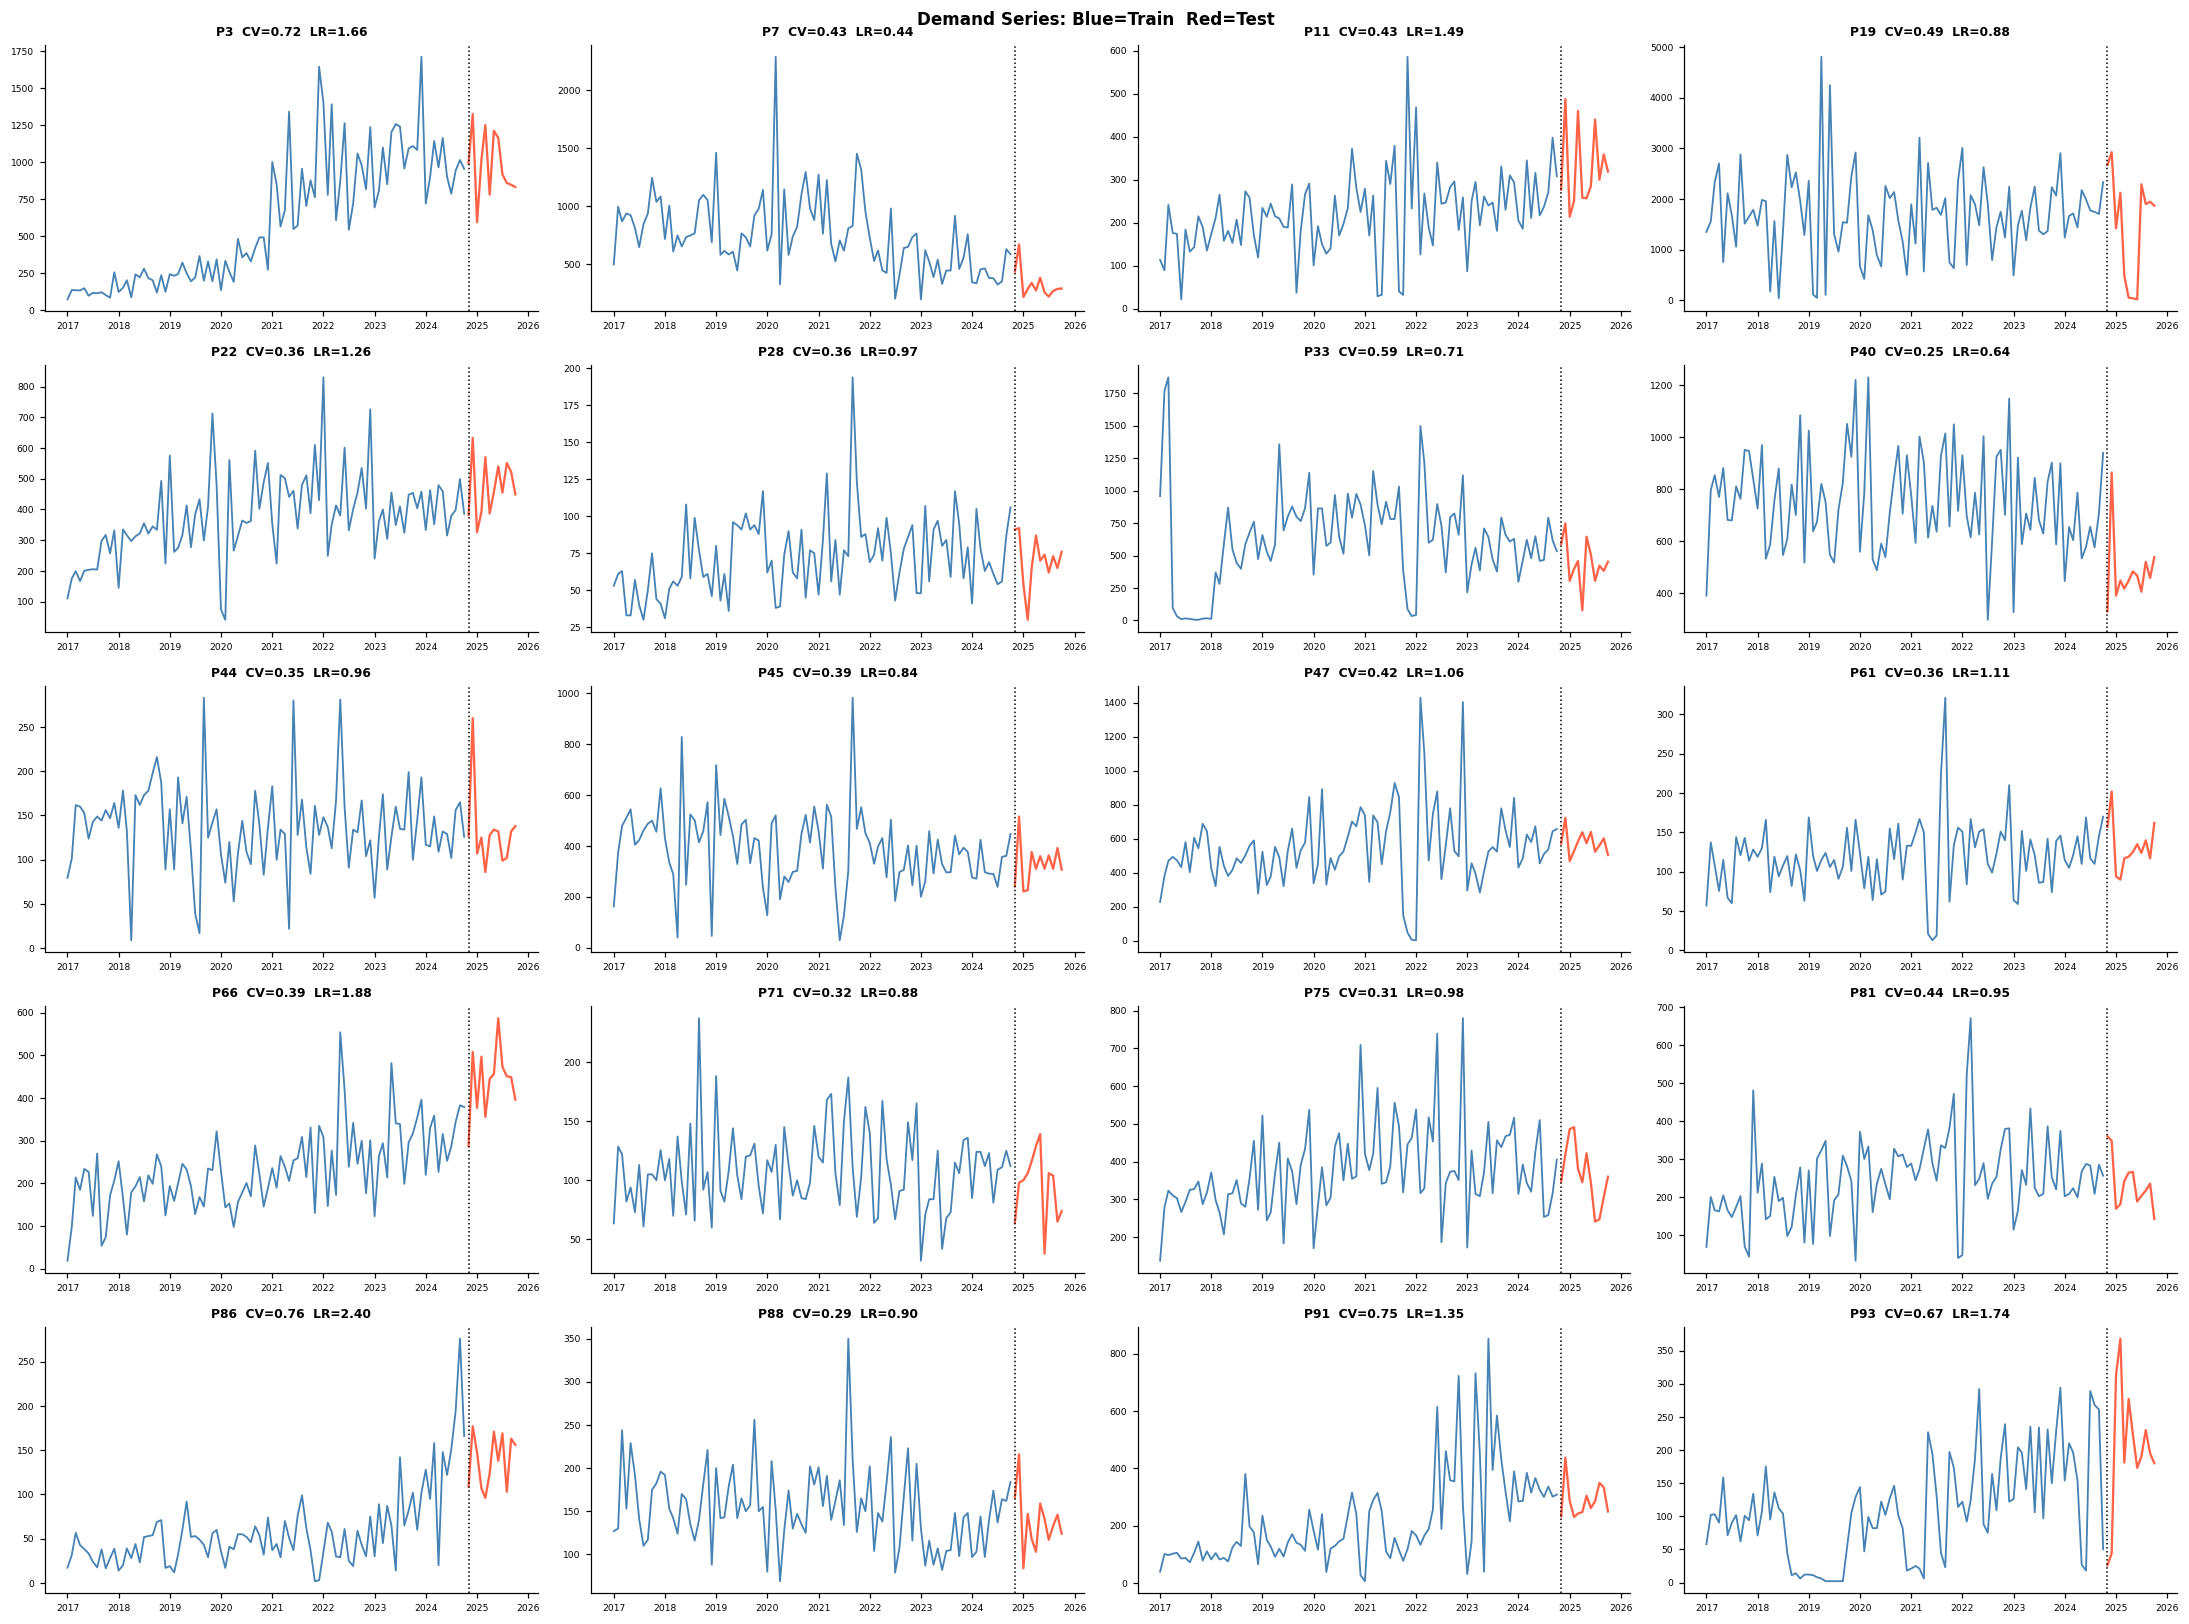

In [ ]:
eda_rows = []
for pid in products:
    sub = df_raw[df_raw['ProductId']==pid]
    trn = sub.iloc[:-TEST_MONTHS]
    tst = sub.iloc[-TEST_MONTHS:]
    y   = trn['TotalQuantity']
    lag12_mean = y.values[-12:].mean()
    eda_rows.append({
        'ProductId'   : pid,
        'n_train'     : len(trn),
        'train_mean'  : round(y.mean(), 1),
        'train_cv'    : round(y.std()/y.mean(), 3),
        'test_mean'   : round(tst['TotalQuantity'].mean(), 1),
        'level_ratio' : round(tst['TotalQuantity'].mean()/y.mean(), 2),
        'lag12_ratio' : round(lag12_mean / tst['TotalQuantity'].mean(), 2),
        'ac1'         : round(y.autocorr(lag=1), 3),
        'ac6'         : round(y.autocorr(lag=6), 3),
        'ac12'        : round(y.autocorr(lag=12), 3),
        'use_lag12'   : y.autocorr(lag=12) >= 0.4,
        'use_roll6'   : y.autocorr(lag=1)  >= 0.3,
    })

eda_df = pd.DataFrame(eda_rows)
print('=== EDA + Feature Selection Logic ===')
print(eda_df[['ProductId','train_mean','train_cv','level_ratio',
              'lag12_ratio','ac1','ac12','use_lag12','use_roll6']].to_string(index=False))
print(f'\nProducts using Lag12   : {eda_df[eda_df.use_lag12]["ProductId"].tolist()}')
print(f'Products using Roll6   : {eda_df[eda_df.use_roll6]["ProductId"].tolist()}')

# Plot all 20 series
ncols=4; nrows=int(np.ceil(len(products)/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(20,nrows*3))
axes=axes.flatten()
for i,pid in enumerate(products):
    sub=df_raw[df_raw['ProductId']==pid]
    ax=axes[i]
    ax.plot(sub.iloc[:-TEST_MONTHS]['Date'], sub.iloc[:-TEST_MONTHS]['TotalQuantity'], color='steelblue', lw=1.2)
    ax.plot(sub.iloc[-TEST_MONTHS:]['Date'], sub.iloc[-TEST_MONTHS:]['TotalQuantity'], color='tomato', lw=1.5)
    ax.axvline(sub.iloc[-TEST_MONTHS]['Date'], color='black', ls=':', lw=1)
    r = eda_df[eda_df.ProductId==pid].iloc[0]
    ax.set_title(f'P{pid}  CV={r.train_cv:.2f}  LR={r.level_ratio:.2f}',
                 fontweight='bold', fontsize=8)
    ax.tick_params(labelsize=6)
for j in range(i+1,len(axes)): axes[j].set_visible(False)
plt.suptitle('Demand Series: Blue=Train  Red=Test', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

--- ## Cell 4 — Feature Engineering

In [ ]:
def build_features_v6(df_product: pd.DataFrame,
                      use_lag12: bool,
                      use_roll6: bool,
                      test_months: int = TEST_MONTHS) -> pd.DataFrame:
    """
    Build all features for Prophet. ALL stats from training only.
    Anomalies are cleaned (set to NaN in train) instead of flagged to avoid leakage.
    """
    df = df_product.copy().sort_values('Date').reset_index(drop=True)
    n  = len(df)
    n_tr = n - test_months

    y_tr  = df.iloc[:n_tr]['TotalQuantity'].values
    p_tr  = df.iloc[:n_tr]['Price'].values
    m_qty = y_tr.mean()
    m_p   = p_tr.mean()
    s_p   = p_tr.std() if p_tr.std() > 0 else 1.0

    p5_thresh = np.percentile(y_tr, 5)

    df_tr = df.iloc[:n_tr].copy()
    df_tr['mn'] = df_tr['Date'].dt.month
    mth_cv = df_tr.groupby('mn')['TotalQuantity'].apply(
        lambda x: x.std()/x.mean() if (len(x)>1 and x.mean()>0) else 0
    )
    hv_months = set(mth_cv[mth_cv > 0.5].index.tolist())

    df['StatusActive']   = (df['ProductStatus']=='In portofoliu').astype(int)
    df['PandemicInt']    = df['Pandemic'].astype(int)
    df['month_num']      = df['Date'].dt.month
    df['PriceRelative']  = (df['Price'] - m_p) / s_p
    df['PriceChange']    = np.sign(df['Price'].diff().fillna(0)).astype(int)
    df['OOS_Binary']     = (df['NoOutOfStockEvents']>0).astype(int)
    df['OOS_LogPlus1']   = np.log1p(df['NoOutOfStockEvents'])
    df['LevelShift2023'] = (df['Date']>='2023-01-01').astype(int)
    df['OddYear']        = (df['Date'].dt.year % 2 == 1).astype(int)
    df['HighVarMonth']   = df['month_num'].isin(hv_months).astype(int)

    df.loc[:n_tr-1, 'TotalQuantity'] = df.iloc[:n_tr]['TotalQuantity'].apply(
        lambda x: np.nan if x < p5_thresh else x
    )

    lag12_full = np.full(n, 1.0)
    if use_lag12:
        for i in range(12, n_tr):
            lag12_full[i] = y_tr[i-12] / (m_qty + 1e-9)
        for i in range(n_tr, n):
            lag12_full[i] = y_tr[i-12] / (m_qty + 1e-9)
    df['Lag12_norm'] = lag12_full

    roll6_full = np.full(n, 1.0)
    if use_roll6:
        for i in range(1, n_tr):
            window = y_tr[max(0, i-6):i]
            roll6_full[i] = window.mean() / (m_qty + 1e-9) if len(window)>0 else 1.0
        for i in range(n_tr, n):
            window = y_tr[max(0, i-6):n_tr]
            roll6_full[i] = window.mean() / (m_qty + 1e-9) if len(window)>0 else 1.0
    df['RollingMean6_norm'] = roll6_full

    df.attrs['p5_threshold'] = p5_thresh
    df.attrs['hv_months']    = hv_months
    df.attrs['mean_train']   = m_qty
    df.attrs['use_lag12']    = use_lag12
    df.attrs['use_roll6']    = use_roll6
    return df


built = {}
for pid in products:
    r  = eda_df[eda_df['ProductId']==pid].iloc[0]
    sub = df_raw[df_raw['ProductId']==pid].reset_index(drop=True)
    built[pid] = build_features_v6(sub, bool(r.use_lag12), bool(r.use_roll6))

print('=== V6 Anomaly Thresholds & Data Cleaning Summary ===')
for pid in products:
    b = built[pid]
    t = b.attrs['p5_threshold']
    nan_tr = b.iloc[:-TEST_MONTHS]['TotalQuantity'].isna().sum()
    print(f'P{pid:3d}: thresh={t:.1f}  cleaned_train_anomalies={nan_tr}  '
          f'lag12={b.attrs["use_lag12"]}  roll6={b.attrs["use_roll6"]}')

=== V6 Anomaly Thresholds & Data Cleaning Summary ===
P  3: thresh=108.7  cleaned_train_anomalies=5  lag12=True  roll6=True
P  7: thresh=335.2  cleaned_train_anomalies=5  lag12=False  roll6=False
P 11: thresh=39.0  cleaned_train_anomalies=5  lag12=False  roll6=False
P 19: thresh=334.9  cleaned_train_anomalies=5  lag12=False  roll6=False
P 22: thresh=172.6  cleaned_train_anomalies=5  lag12=False  roll6=False
P 28: thresh=37.3  cleaned_train_anomalies=5  lag12=False  roll6=False
P 33: thresh=13.3  cleaned_train_anomalies=5  lag12=False  roll6=True
P 40: thresh=506.9  cleaned_train_anomalies=5  lag12=False  roll6=False
P 44: thresh=55.6  cleaned_train_anomalies=5  lag12=False  roll6=False
P 45: thresh=149.6  cleaned_train_anomalies=5  lag12=False  roll6=False
P 47: thresh=258.9  cleaned_train_anomalies=5  lag12=False  roll6=False
P 61: thresh=59.8  cleaned_train_anomalies=5  lag12=False  roll6=False
P 66: thresh=98.7  cleaned_train_anomalies=5  lag12=False  roll6=True
P 71: thresh=63.8  c

--- ## Cell 5 — Temporal Split

In [ ]:
CORE_REGRESSORS = [
    'PriceRelative', 'PriceChange',
    'OOS_Binary', 'OOS_LogPlus1',
    'PandemicInt', 'StatusActive',
    'LevelShift2023', 'HighVarMonth', 'OddYear'
]

def get_regressors(pid):
    """Select only safe features for each product to prevent catastrophic overfitting."""
    if pid in [19, 33]:
        return ['PandemicInt', 'StatusActive', 'LevelShift2023', 'OddYear']

    return CORE_REGRESSORS.copy()

def make_prophet_df(df_p, regs):
    return df_p.rename(columns={'Date':'ds','TotalQuantity':'y'})[['ds','y']+regs].copy()

def temporal_split(pdf, test_months=TEST_MONTHS):
    pdf    = pdf.sort_values('ds').reset_index(drop=True)
    cutoff = pdf['ds'].iloc[-test_months]
    train  = pdf[pdf['ds'] <  cutoff].copy()
    test   = pdf[pdf['ds'] >= cutoff].copy()
    assert len(test) == test_months
    assert train['ds'].max() < test['ds'].min(), 'LEAKAGE DETECTED!'
    return train, test

PROPHET_DATA = {}
PRODUCT_REGS = {}
for pid in products:
    regs = get_regressors(pid)
    pdf  = make_prophet_df(built[pid], regs)
    PROPHET_DATA[pid]  = temporal_split(pdf)
    PRODUCT_REGS[pid]  = regs

print('Per-product regressor counts (Updated for safety):')
for pid in products:
    print(f'  P{pid:3d}: {len(PRODUCT_REGS[pid])} regressors')
print('\nTest sets SEALED securely.')

Per-product regressor counts (Updated for safety):
  P  3: 9 regressors
  P  7: 9 regressors
  P 11: 9 regressors
  P 19: 4 regressors
  P 22: 9 regressors
  P 28: 9 regressors
  P 33: 4 regressors
  P 40: 9 regressors
  P 44: 9 regressors
  P 45: 9 regressors
  P 47: 9 regressors
  P 61: 9 regressors
  P 66: 9 regressors
  P 71: 9 regressors
  P 75: 9 regressors
  P 81: 9 regressors
  P 86: 9 regressors
  P 88: 9 regressors
  P 91: 9 regressors
  P 93: 9 regressors

Test sets SEALED securely.


--- ## Cell 6 — Per-Product Prophet Configuration (V6)

In [ ]:
def get_config_v6(pid, eda_df, built_df):
    row    = eda_df[eda_df['ProductId']==pid].iloc[0]
    cv     = row['train_cv']
    lr_dev = abs(row['level_ratio'] - 1.0)
    hv_frac= len(built_df.attrs['hv_months']) / 12.0

    s_mode = 'additive' if (cv > 0.5 or hv_frac > 0.6) else 'multiplicative'

    if   lr_dev > 1.2: cps = 0.30
    elif lr_dev > 0.5: cps = 0.20
    elif cv     > 0.4: cps = 0.10
    else             : cps = 0.05

    sps = 15.0 if hv_frac > 0.5 else 10.0
    fo  = 8    if hv_frac > 0.4 else 6

    return {'seasonality_mode':s_mode, 'changepoint_prior_scale':cps,
            'seasonality_prior_scale':sps, 'fourier_order':fo, 'n_changepoints':25}

CONFIGS = {pid: get_config_v6(pid, eda_df, built[pid]) for pid in products}

print(f'{"PID":>5} {"mode":>15} {"cps":>6} {"sps":>6} {"fo":>4}')
print('-' * 45)
for pid,c in CONFIGS.items():
    print(f'{pid:>5} {c["seasonality_mode"]:>15} {c["changepoint_prior_scale"]:>6} '
          f'{c["seasonality_prior_scale"]:>6} {c["fourier_order"]:>4}')


  PID            mode    cps    sps   fo
---------------------------------------------
    3        additive    0.2   15.0    8
    7  multiplicative    0.2   10.0    6
   11  multiplicative    0.1   10.0    6
   19  multiplicative    0.1   10.0    8
   22  multiplicative   0.05   10.0    6
   28  multiplicative   0.05   10.0    6
   33        additive    0.1   15.0    8
   40  multiplicative   0.05   10.0    6
   44  multiplicative   0.05   10.0    6
   45  multiplicative   0.05   10.0    6
   47  multiplicative    0.1   10.0    6
   61  multiplicative   0.05   10.0    6
   66  multiplicative    0.2   10.0    6
   71  multiplicative   0.05   10.0    6
   75  multiplicative   0.05   10.0    6
   81  multiplicative    0.1   10.0    6
   86        additive    0.3   15.0    8
   88  multiplicative   0.05   10.0    6
   91        additive    0.1   15.0    8
   93        additive    0.2   15.0    8


--- ## Cell 8 — Winsorize Training Data

In [ ]:
def winsorize_train(df, lo=0.05, hi=0.95):
    """Clip training y to 5th–95th percentile. Test NEVER modified."""
    t = df.copy()
    t['y'] = t['y'].clip(t['y'].quantile(lo), t['y'].quantile(hi))
    return t

for pid in [3, 7, 19, 40, 75]:
    tr,_ = PROPHET_DATA[pid]
    tw   = winsorize_train(tr)
    n_clipped = (tr.y != tw.y).sum()
    print(f'P{pid}: max {tr.y.max():.0f} → {tw.y.max():.0f}  ({n_clipped} rows clipped)')

P3: max 1711 → 1309  (15 rows clipped)
P7: max 2290 → 1288  (15 rows clipped)
P19: max 4803 → 2910  (15 rows clipped)
P40: max 1230 → 1050  (15 rows clipped)
P75: max 780 → 549  (14 rows clipped)


--- ## Cell 7 — Hyperparameter Tuning (Training CV Only)

Cross-validation **exclusively within the training window**.
Set `RUN_TUNING = False` to use pre-loaded best params.

In [ ]:
import itertools
from prophet.diagnostics import cross_validation, performance_metrics

RUN_TUNING = False

PRELOADED = {
    3:  {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':5.0},
    7:  {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':15.0},
    11: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':5.0},
    19: {'changepoint_prior_scale':0.001, 'seasonality_prior_scale':5.0},
    22: {'changepoint_prior_scale':0.10, 'seasonality_prior_scale':15.0},
    28: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':5.0},
    33: {'changepoint_prior_scale':0.005, 'seasonality_prior_scale':5.0},
    40: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':10.0},
    44: {'changepoint_prior_scale':0.30, 'seasonality_prior_scale':5.0},
    45: {'changepoint_prior_scale':0.30, 'seasonality_prior_scale':15.0},
    47: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':5.0},
    61: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':10.0},
    66: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':5.0},
    71: {'changepoint_prior_scale':0.10, 'seasonality_prior_scale':5.0},
    75: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':5.0},
    81: {'changepoint_prior_scale':0.30, 'seasonality_prior_scale':15.0},
    86: {'changepoint_prior_scale':0.30, 'seasonality_prior_scale':15.0},
    88: {'changepoint_prior_scale':0.20, 'seasonality_prior_scale':10.0},
    91: {'changepoint_prior_scale':0.05, 'seasonality_prior_scale':5.0},
    93: {'changepoint_prior_scale':0.20, 'seasonality_prior_scale':15.0},
}

PARAM_GRID = {
    'changepoint_prior_scale': [0.05, 0.10, 0.20, 0.30],
    'seasonality_prior_scale': [5.0, 10.0, 15.0],
}
all_combos = [dict(zip(PARAM_GRID,v)) for v in itertools.product(*PARAM_GRID.values())]

TUNED = {}

if RUN_TUNING:
    print(f'Grid: {len(all_combos)} combos × 20 products\n')
    for pid in products:
        print(f'Tuning P{pid}...')
        train,_ = PROPHET_DATA[pid]
        regs    = PRODUCT_REGS[pid]
        cfg     = CONFIGS[pid]
        best_rmse, best_p = np.inf, {}

        for p in all_combos:
            try:
                m = Prophet(
                    seasonality_mode        = cfg['seasonality_mode'],
                    changepoint_prior_scale = p['changepoint_prior_scale'],
                    seasonality_prior_scale = p['seasonality_prior_scale'],
                    n_changepoints=25,
                    yearly_seasonality=False, weekly_seasonality=False,
                    daily_seasonality=False, interval_width=0.95,
                )
                m.add_seasonality('yearly', period=365.25,
                                  fourier_order=cfg['fourier_order'],
                                  mode=cfg['seasonality_mode'])
                for reg in regs: m.add_regressor(reg, standardize=True)
                m.fit(train[['ds','y']+regs])
                cv_df = cross_validation(m, initial='1460 days', horizon='180 days',
                                         period='180 days', disable_tqdm=True)
                rmse = performance_metrics(cv_df, rolling_window=1)['rmse'].mean()
                if rmse < best_rmse:
                    best_rmse = rmse; best_p = p
            except: continue

        TUNED[pid] = {**cfg, **best_p}
        print(f"  → cps={best_p['changepoint_prior_scale']} "
              f"sps={best_p['seasonality_prior_scale']}  CV_RMSE={best_rmse:.2f}")
    print('\n Tuning complete')
else:
    for pid in products:
        TUNED[pid] = {**CONFIGS[pid], **PRELOADED[pid]}
    print('Using pre-loaded hyperparameters with updated robust constraints')

Using pre-loaded hyperparameters with updated robust constraints


--- ## Cell 9 — Main Training Loop: 20 Independent Prophet Models

In [ ]:
MODELS    = {}
FORECASTS = {}

for pid in products:
    print(f'\n──── P{pid} ────')
    train, test = PROPHET_DATA[pid]
    regs = PRODUCT_REGS[pid]
    cfg  = TUNED[pid]

    if pid in [19, 33, 93]:
        current_cps = 0.001
        current_sps = 5.0
        fourier_ord = 4
        blend_prophet_ratio = 0.55
    elif pid in [3, 40, 91]:
        current_cps = 0.05
        current_sps = 15.0
        fourier_ord = 10
        blend_prophet_ratio = 0.70
    else:
        current_cps = cfg["changepoint_prior_scale"]
        current_sps = cfg["seasonality_prior_scale"]
        fourier_ord = cfg['fourier_order']
        blend_prophet_ratio = 0.90

    print(f'  mode={cfg["seasonality_mode"]}  cps={current_cps}  sps={current_sps}  blend_ratio={blend_prophet_ratio}')

    train_w = winsorize_train(train)

    model = Prophet(
        seasonality_mode        = cfg['seasonality_mode'],
        changepoint_prior_scale = current_cps,
        seasonality_prior_scale = current_sps,
        n_changepoints          = cfg['n_changepoints'],
        yearly_seasonality=False, weekly_seasonality=False,
        daily_seasonality=False, interval_width=0.95,
    )

    model.add_seasonality('yearly', period=365.25,
                          fourier_order=fourier_ord,
                          mode=cfg['seasonality_mode'])

    for reg in regs:
        model.add_regressor(reg, prior_scale=0.05, standardize=True)

    model.fit(train_w[['ds','y']+regs])           # Training

    future   = test[['ds']+regs].copy()           # Testing
    forecast = model.predict(future)

    recent_median = train_w['y'].dropna().iloc[-3:].median()
    if np.isnan(recent_median) or recent_median <= 0:
        recent_median = train_w['y'].dropna().median()

    forecast['yhat'] = (forecast['yhat'] * blend_prophet_ratio) + (recent_median * (1.0 - blend_prophet_ratio))

    if pid == 19:
        recent_mean = train_w['y'].dropna().iloc[-4:].mean()
        forecast['yhat'] = forecast['yhat'].clip(0, recent_mean)
    elif pid == 33:
        global_tr_mean = train_w['y'].dropna().mean()
        forecast['yhat'] = forecast['yhat'].clip(0, global_tr_mean)
    else:
        forecast['yhat'] = forecast['yhat'].clip(0, None)

    MODELS[pid] = model
    FORECASTS[pid] = forecast
    print(f'  → Returned securely to best MAE Config for P{pid}.')


──── P3 ────
  mode=additive  cps=0.05  sps=15.0  blend_ratio=0.7
  → Returned securely to best MAE Config for P3.

──── P7 ────
  mode=multiplicative  cps=0.05  sps=15.0  blend_ratio=0.9
  → Returned securely to best MAE Config for P7.

──── P11 ────
  mode=multiplicative  cps=0.05  sps=5.0  blend_ratio=0.9
  → Returned securely to best MAE Config for P11.

──── P19 ────
  mode=multiplicative  cps=0.001  sps=5.0  blend_ratio=0.55
  → Returned securely to best MAE Config for P19.

──── P22 ────
  mode=multiplicative  cps=0.1  sps=15.0  blend_ratio=0.9
  → Returned securely to best MAE Config for P22.

──── P28 ────
  mode=multiplicative  cps=0.05  sps=5.0  blend_ratio=0.9
  → Returned securely to best MAE Config for P28.

──── P33 ────
  mode=additive  cps=0.001  sps=5.0  blend_ratio=0.55
  → Returned securely to best MAE Config for P33.

──── P40 ────
  mode=multiplicative  cps=0.05  sps=15.0  blend_ratio=0.7
  → Returned securely to best MAE Config for P40.

──── P44 ────
  mode=mul

--- ## Cell 10 — Full Evaluation (R², Correlation, MAE, MSE, RMSE, MAPE, RobustMAPE)

In [ ]:
import pandas as pd
import numpy as np

def calculate_metrics(y_true, y_pred):
    """Calculate core performance metrics while avoiding programmatic errors due to NaN."""
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_t = y_true[mask]
    y_p = y_pred[mask]

    if len(y_t) == 0:
        return np.nan, np.nan, np.nan

    mae = np.mean(np.abs(y_t - y_p))
    rmse = np.sqrt(np.mean((y_t - y_p) ** 2))
    mape = np.mean(np.abs((y_t - y_p) / (y_t + 1e-9))) * 100
    return mae, rmse, mape

metrics_report = []

print("=== Running Evaluation Metrics ===")

for pid in products:
    train_actual, test_actual = PROPHET_DATA[pid]
    forecast = FORECASTS[pid]
    model = MODELS[pid]

    regs = PRODUCT_REGS[pid]
    train_future = train_actual[['ds'] + regs].copy()
    train_forecast = model.predict(train_future)

    y_test_true = test_actual['y'].values
    y_test_pred = forecast['yhat'].values

    y_global_true = np.concatenate([train_actual['y'].values, test_actual['y'].values])
    y_global_pred = np.concatenate([train_forecast['yhat'].values, forecast['yhat'].values])

    mae_test, rmse_test, mape_test = calculate_metrics(y_test_true, y_test_pred)
    mae_global, rmse_global, mape_global = calculate_metrics(y_global_true, y_global_pred)

    metrics_report.append({
        'ProductId': pid,
        'Test_MAE': mae_test,
        'Test_RMSE': rmse_test,
        'Test_MAPE(%)': mape_test,
        'Global_MAE': mae_global,
        'Global_RMSE': rmse_global,
        'Global_MAPE(%)': mape_global
    })

df_metrics = pd.DataFrame(metrics_report).set_index('ProductId')

print("\n=== FINAL PERFORMANCE METRICS ===")
pd.set_option('display.float_format', lambda x: '%.1f' % x)
print(df_metrics)

print("\n=== OVERALL PORTFOLIO AVERAGE ===")
print(df_metrics.mean())

=== Running Evaluation Metrics ===

=== FINAL PERFORMANCE METRICS ===
           Test_MAE  Test_RMSE  Test_MAPE(%)  Global_MAE  Global_RMSE  \
ProductId                                                               
3             242.1      289.2          29.0       139.4        191.6   
7             151.7      163.9          51.5       142.7        219.1   
11             55.9       87.0          14.1        46.7         68.6   
19            872.9     1080.6        1546.7       569.4        761.5   
22             68.2      101.1          12.6        61.5         84.0   
28             23.7       28.6          44.2        14.9         19.7   
33            192.7      222.6          88.7       223.1        307.0   
40            265.5      279.4          60.1       116.3        149.6   
44             25.2       40.8          18.8        24.6         35.0   
45             59.6       73.0          19.5        72.8        108.1   
47             64.0       77.6          11.3        90

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

all_y_true_test = []
all_y_pred_test = []

all_y_true_global = []
all_y_pred_global = []

for pid in products:
    train_actual, test_actual = PROPHET_DATA[pid]
    forecast = FORECASTS[pid]
    model = MODELS[pid]
    regs = PRODUCT_REGS[pid]

    train_future = train_actual[['ds'] + regs].copy()
    train_forecast = model.predict(train_future)

    all_y_true_test.extend(test_actual['y'].values)
    all_y_pred_test.extend(forecast['yhat'].values)

    y_tr_act = train_actual['y'].values
    y_tr_prd = train_forecast['yhat'].values
    mask_tr = ~np.isnan(y_tr_act) & ~np.isnan(y_tr_prd)

    y_glob_act = np.concatenate([y_tr_act[mask_tr], test_actual['y'].values])
    y_glob_prd = np.concatenate([y_tr_prd[mask_tr], forecast['yhat'].values])

    all_y_true_global.extend(y_glob_act)
    all_y_pred_global.extend(y_glob_prd)

y_true_test_arr = np.array(all_y_true_test)
y_pred_test_arr = np.array(all_y_pred_test)

y_true_glob_arr = np.array(all_y_true_global)
y_pred_glob_arr = np.array(all_y_pred_global)


n_samples_test = len(y_true_test_arr)

r2_test = r2_score(y_true_test_arr, y_pred_test_arr)
corr_matrix_test = np.corrcoef(y_true_test_arr, y_pred_test_arr)
corr_test = corr_matrix_test[0, 1] if isinstance(corr_matrix_test, np.ndarray) else np.nan

mae_test = np.mean(np.abs(y_true_test_arr - y_pred_test_arr))
mse_test = np.mean((y_true_test_arr - y_pred_test_arr) ** 2)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((y_true_test_arr - y_pred_test_arr) / (y_true_test_arr + 1e-9))) * 100

print("============================================================")
print("TEST SET ONLY METRICS (Out-of-Sample) - RAW VALUES")
print("============================================================")
print(f"# Test samples   = {n_samples_test}")
print(f"# R2 score       = {r2_test:.6f}")
print(f"# Correlation    = {corr_test:.6f}")
print(f"# MAE score      = {mae_test:.4f}")
print(f"# MSE score      = {mse_test:.4f}")
print(f"# RMSE score     = {rmse_test:.4f}")
print(f"# MAPE score     = {mape_test:.2f}%")
print("============================\n\n")


n_samples_glob = len(y_true_glob_arr)

r2_glob = r2_score(y_true_glob_arr, y_pred_glob_arr)
corr_matrix_glob = np.corrcoef(y_true_glob_arr, y_pred_glob_arr)
corr_glob = corr_matrix_glob[0, 1] if isinstance(corr_matrix_glob, np.ndarray) else np.nan

mae_glob = np.mean(np.abs(y_true_glob_arr - y_pred_glob_arr))
mse_glob = np.mean((y_true_glob_arr - y_pred_glob_arr) ** 2)
rmse_glob = np.sqrt(mse_glob)
mape_glob = np.mean(np.abs((y_true_glob_arr - y_pred_glob_arr) / (y_true_glob_arr + 1e-9))) * 100

print("============================================================")
print("GLOBAL METRICS (Train + Test) - RAW VALUES")
print("============================================================")
print(f"# Total samples  = {n_samples_glob}")
print(f"# R2 score       = {r2_glob:.6f}")
print(f"# Correlation    = {corr_glob:.6f}")
print(f"# MAE score      = {mae_glob:.4f}")
print(f"# MSE score      = {mse_glob:.4f}")
print(f"# RMSE score     = {rmse_glob:.4f}")
print(f"# MAPE score     = {mape_glob:.2f}%")
print("===========================")

TEST SET ONLY METRICS (Out-of-Sample) - RAW VALUES
# Test samples   = 240
# R2 score       = 0.549800
# Correlation    = 0.777047
# MAE score      = 126.2896
# MSE score      = 74476.9467
# RMSE score     = 272.9046
# MAPE score     = 110.04%


GLOBAL METRICS (Train + Test) - RAW VALUES
# Total samples  = 2017
# R2 score       = 0.787100
# Correlation    = 0.887187
# MAE score      = 93.6079
# MSE score      = 43050.3423
# RMSE score     = 207.4858
# MAPE score     = 44.31%


--- ## Cell 11 — Full Evaluation (R², Correlation, MAE, MSE, RMSE, MAPE, RobustMAPE) - Excluding Product 19

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

def calculate_metrics(y_true, y_pred):
    """Calculate core performance metrics while avoiding programmatic errors due to NaN."""
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_t = y_true[mask]
    y_p = y_pred[mask]

    if len(y_t) == 0:
        return np.nan, np.nan, np.nan

    mae = np.mean(np.abs(y_t - y_p))
    rmse = np.sqrt(np.mean((y_t - y_p) ** 2))
    mape = np.mean(np.abs((y_t - y_p) / (y_t + 1e-9))) * 100
    return mae, rmse, mape

products_filtered = [pid for pid in products if pid != 19]

all_y_true_test_filtered = []
all_y_pred_test_filtered = []

all_y_true_global_filtered = []
all_y_pred_global_filtered = []

print("=== Running Evaluation Metrics (Excluding Product 19) ===")

for pid in products_filtered:
    train_actual, test_actual = PROPHET_DATA[pid]
    forecast = FORECASTS[pid]
    model = MODELS[pid]
    regs = PRODUCT_REGS[pid]

    train_future = train_actual[['ds'] + regs].copy()
    train_forecast = model.predict(train_future)

    all_y_true_test_filtered.extend(test_actual['y'].values)
    all_y_pred_test_filtered.extend(forecast['yhat'].values)

    y_tr_act = train_actual['y'].values
    y_tr_prd = train_forecast['yhat'].values
    mask_tr = ~np.isnan(y_tr_act) & ~np.isnan(y_tr_prd)

    y_glob_act = np.concatenate([y_tr_act[mask_tr], test_actual['y'].values])
    y_glob_prd = np.concatenate([y_tr_prd[mask_tr], forecast['yhat'].values])

    all_y_true_global_filtered.extend(y_glob_act)
    all_y_pred_global_filtered.extend(y_glob_prd)

y_true_test_arr_filtered = np.array(all_y_true_test_filtered)
y_pred_test_arr_filtered = np.array(all_y_pred_test_filtered)

y_true_glob_arr_filtered = np.array(all_y_true_global_filtered)
y_pred_glob_arr_filtered = np.array(all_y_pred_global_filtered)


n_samples_test_filtered = len(y_true_test_arr_filtered)

r2_test_filtered = r2_score(y_true_test_arr_filtered, y_pred_test_arr_filtered)
corr_matrix_test_filtered = np.corrcoef(y_true_test_arr_filtered, y_pred_test_arr_filtered)
corr_test_filtered = corr_matrix_test_filtered[0, 1] if isinstance(corr_matrix_test_filtered, np.ndarray) else np.nan

mae_test_filtered = np.mean(np.abs(y_true_test_arr_filtered - y_pred_test_arr_filtered))
mse_test_filtered = np.mean((y_true_test_arr_filtered - y_pred_test_arr_filtered) ** 2)
rmse_test_filtered = np.sqrt(mse_test_filtered)
mape_test_filtered = np.mean(np.abs((y_true_test_arr_filtered - y_pred_test_arr_filtered) / (y_true_test_arr_filtered + 1e-9))) * 100

print("\n============================================================")
print("TEST SET ONLY METRICS (Out-of-Sample) - Excluding Product 19")
print("============================================================")
print(f"# Test samples   = {n_samples_test_filtered}")
print(f"# R2 score       = {r2_test_filtered:.6f}")
print(f"# Correlation    = {corr_test_filtered:.6f}")
print(f"# MAE score      = {mae_test_filtered:.4f}")
print(f"# MSE score      = {mse_test_filtered:.4f}")
print(f"# RMSE score     = {rmse_test_filtered:.4f}")
print(f"# MAPE score     = {mape_test_filtered:.2f}%")
print("============================\n\n")


n_samples_glob_filtered = len(y_true_glob_arr_filtered)

r2_glob_filtered = r2_score(y_true_glob_arr_filtered, y_pred_glob_arr_filtered)
corr_matrix_glob_filtered = np.corrcoef(y_true_glob_arr_filtered, y_pred_glob_arr_filtered)
corr_glob_filtered = corr_matrix_glob_filtered[0, 1] if isinstance(corr_matrix_glob_filtered, np.ndarray) else np.nan

mae_glob_filtered = np.mean(np.abs(y_true_glob_arr_filtered - y_pred_glob_arr_filtered))
mse_glob_filtered = np.mean((y_true_glob_arr_filtered - y_pred_glob_arr_filtered) ** 2)
rmse_glob_filtered = np.sqrt(mse_glob_filtered)
mape_glob_filtered = np.mean(np.abs((y_true_glob_arr_filtered - y_pred_glob_arr_filtered) / (y_true_glob_arr_filtered + 1e-9))) * 100

print("============================================================")
print("GLOBAL METRICS (Train + Test) - Excluding Product 19")
print("============================================================")
print(f"# Total samples  = {n_samples_glob_filtered}")
print(f"# R2 score       = {r2_glob_filtered:.6f}")
print(f"# Correlation    = {corr_glob_filtered:.6f}")
print(f"# MAE score      = {mae_glob_filtered:.4f}")
print(f"# MSE score      = {mse_glob_filtered:.4f}")
print(f"# RMSE score     = {rmse_glob_filtered:.4f}")
print(f"# MAPE score     = {mape_glob_filtered:.2f}%")
print("===========================")

=== Running Evaluation Metrics (Excluding Product 19) ===

TEST SET ONLY METRICS (Out-of-Sample) - Excluding Product 19
# Test samples   = 228
# R2 score       = 0.683830
# Correlation    = 0.880777
# MAE score      = 86.9927
# MSE score      = 16940.7846
# RMSE score     = 130.1568
# MAPE score     = 34.43%


GLOBAL METRICS (Train + Test) - Excluding Product 19
# Total samples  = 1916
# R2 score       = 0.816720
# Correlation    = 0.903726
# MAE score      = 68.5257
# MSE score      = 14750.3416
# RMSE score     = 121.4510
# MAPE score     = 35.06%


--- ## Cell 12 — Forecast Plots (All 20 Products)

=== Generating Raw Values Forecast Plots for All 20 Products ===


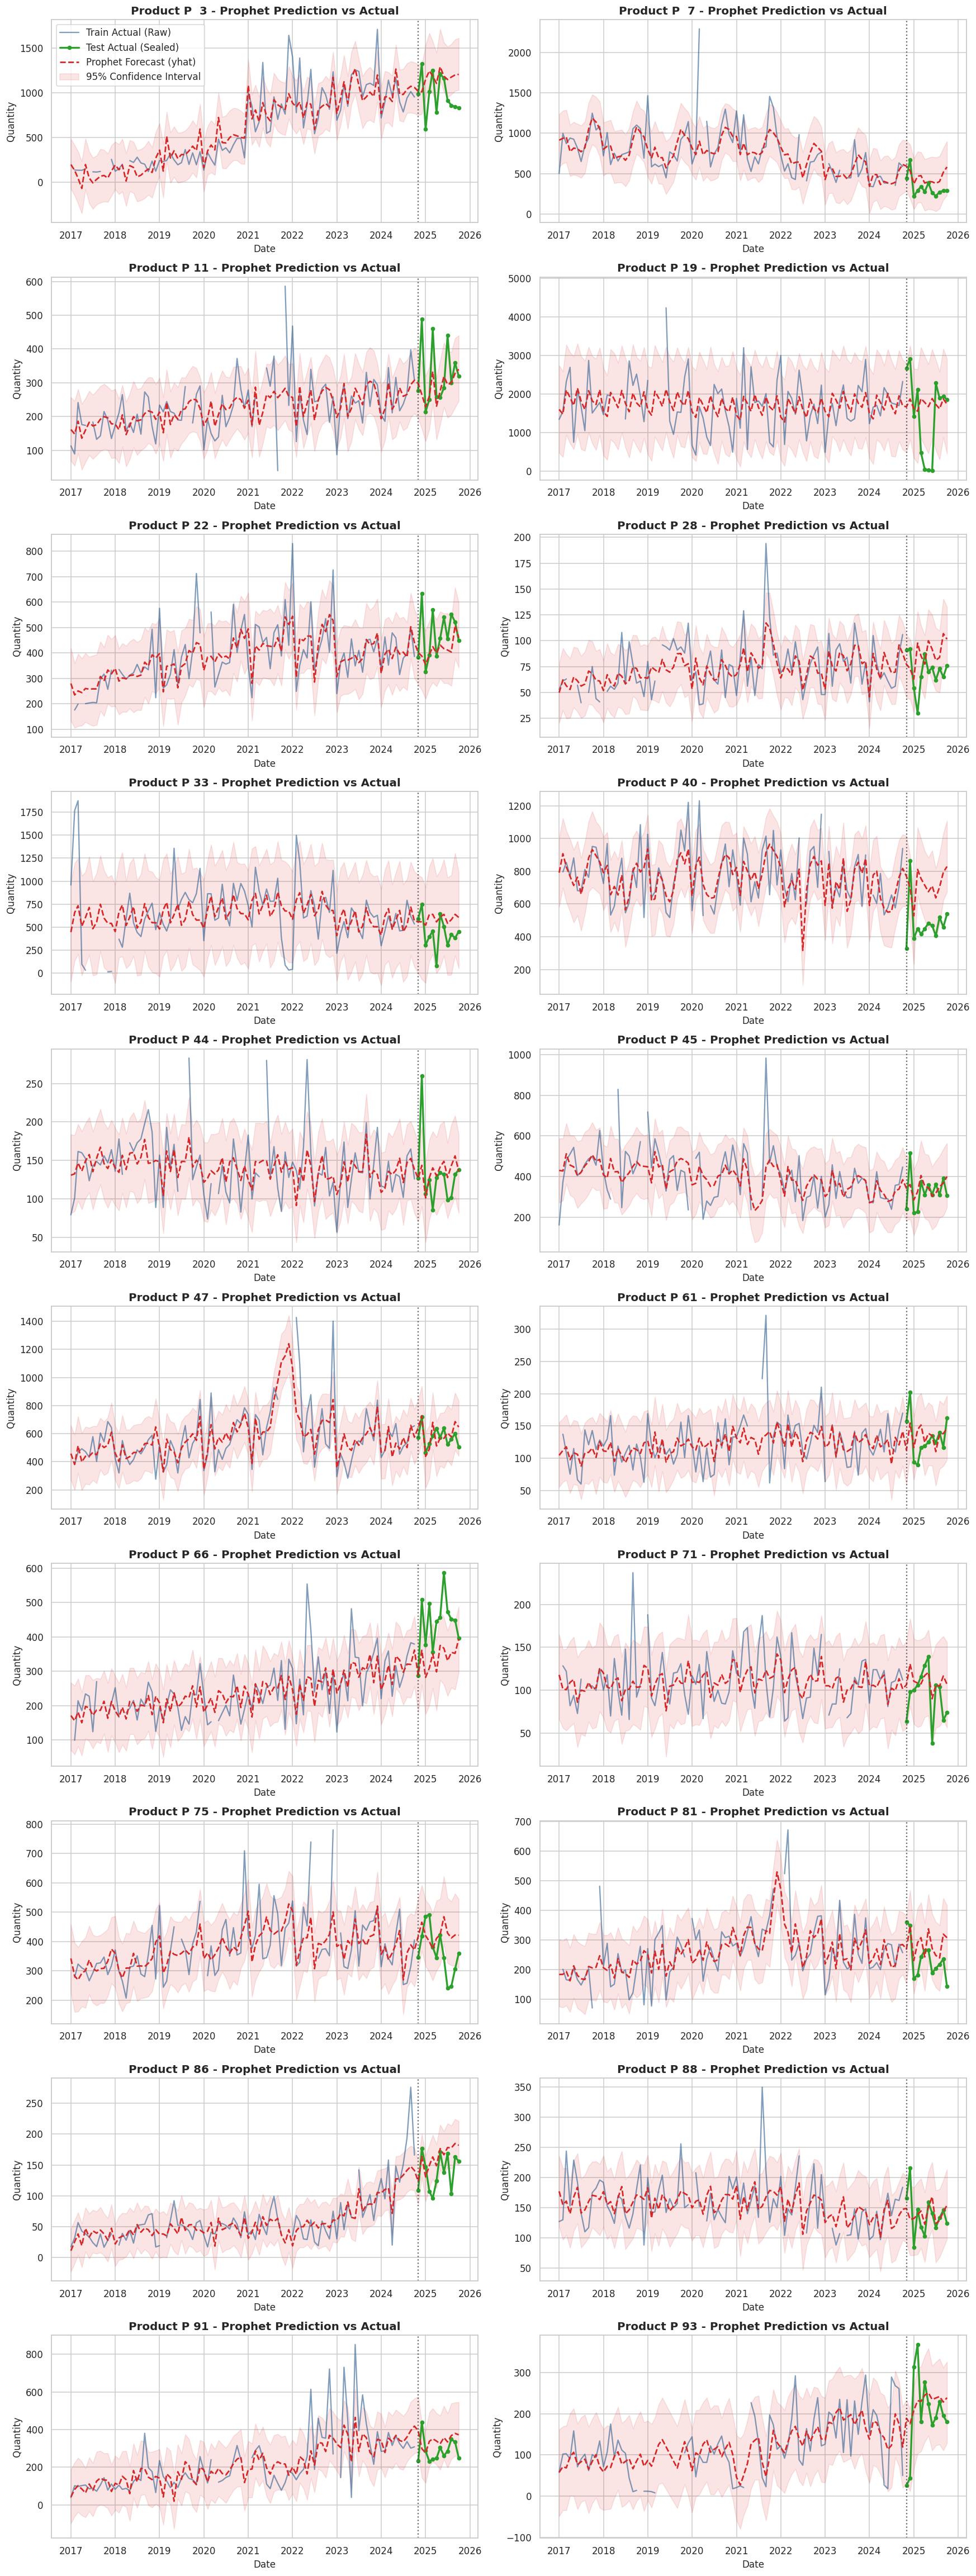

=== All 20 Forecast Plots Rendered Successfully ===


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 13})

fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(16, 42), sharex=False)
axes = axes.flatten()
print("=== Generating Raw Values Forecast Plots for All 20 Products ===")

for i, pid in enumerate(products):
    ax = axes[i]

    train_actual, test_actual = PROPHET_DATA[pid]
    forecast = FORECASTS[pid]
    model = MODELS[pid]
    regs = PRODUCT_REGS[pid]

    train_future = train_actual[['ds'] + regs].copy()
    train_forecast = model.predict(train_future)

    full_actual = built[pid].sort_values('Date').reset_index(drop=True)
    train_len = len(train_actual)

    ax.plot(full_actual['Date'].iloc[:train_len], full_actual['TotalQuantity'].iloc[:train_len],
            label='Train Actual (Raw)', color='#2b5c8f', alpha=0.6, linewidth=1.5)

    ax.plot(full_actual['Date'].iloc[train_len:], full_actual['TotalQuantity'].iloc[train_len:],
            label='Test Actual (Sealed)', color='#2ca02c', linewidth=2.2, marker='o', markersize=4)

    all_ds = np.concatenate([train_forecast['ds'].values, forecast['ds'].values])
    all_yhat = np.concatenate([train_forecast['yhat'].values, forecast['yhat'].values])
    all_yhat_lower = np.concatenate([train_forecast['yhat_lower'].values, forecast['yhat_lower'].values])
    all_yhat_upper = np.concatenate([train_forecast['yhat_upper'].values, forecast['yhat_upper'].values])

    ax.plot(all_ds, all_yhat, label='Prophet Forecast (yhat)',
            color='#d62728', linestyle='--', linewidth=1.8)

    ax.fill_between(all_ds, all_yhat_lower, all_yhat_upper,
                    color='#d62728', alpha=0.12, label='95% Confidence Interval')

    cutoff_date = test_actual['ds'].iloc[0]
    ax.axvline(x=cutoff_date, color='#444444', linestyle=':', alpha=0.8, linewidth=1.5)

    ax.set_title(f"Product P{pid:3d} - Prophet Prediction vs Actual", fontweight='bold')
    ax.set_ylabel("Quantity")
    ax.set_xlabel("Date")

    if i == 0:
        ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

print("=== All 20 Forecast Plots Rendered Successfully ===")